In [ ]:
!pip install -U transformers

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.4/41.4 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 127.3 MB/s eta 0:00:00
  Attempting uninstall: transformers
    Found existing installation: transformers 4.56.2
    Uninstalling transformers-4.56.2:
      Successfully uninstalled transformers-4.56.2


## Local Inference on GPU
Model page: https://huggingface.co/aubmindlab/bert-base-arabertv2

⚠️ If the generated code snippets do not work, please open an issue on either the [model repo](https://huggingface.co/aubmindlab/bert-base-arabertv2)
			and/or on [huggingface.js](https://github.com/huggingface/huggingface.js/blob/main/packages/tasks/src/model-libraries-snippets.ts) 🙏

In [1]:
# Use a pipeline as a high-level helper
from transformers import pipeline

pipe = pipeline("fill-mask", model="aubmindlab/bert-base-arabertv2")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/384 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/543M [00:00<?, ?B/s]

Some weights of the model checkpoint at aubmindlab/bert-base-arabertv2 were not used when initializing BertForMaskedLM: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'cls.seq_relationship.bias', 'cls.seq_relationship.weight']
- This IS expected if you are initializing BertForMaskedLM from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForMaskedLM from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


tokenizer_config.json:   0%|          | 0.00/611 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Device set to use cuda:0


In [2]:
# Load model directly
from transformers import AutoTokenizer, AutoModelForMaskedLM

tokenizer = AutoTokenizer.from_pretrained("aubmindlab/bert-base-arabertv2")
model = AutoModelForMaskedLM.from_pretrained("aubmindlab/bert-base-arabertv2")

Some weights of the model checkpoint at aubmindlab/bert-base-arabertv2 were not used when initializing BertForMaskedLM: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'cls.seq_relationship.bias', 'cls.seq_relationship.weight']
- This IS expected if you are initializing BertForMaskedLM from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForMaskedLM from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


In [3]:
from datasets import load_dataset
import json, os

assert os.path.exists("/content/train_sa_regions.json")
assert os.path.exists("/content/val_sa_regions.json")
assert os.path.exists("/content/label_config_exact.json")

with open("/content/label_config_exact.json","r",encoding="utf-8") as f:
    cfg = json.load(f)

label2id = cfg["label2id"]
id2label = {int(k):v for k,v in cfg["id2label"].items()} if isinstance(list(cfg["id2label"].keys())[0], str) else cfg["id2label"]
num_labels = len(label2id)
print("labels:", label2id, "num_labels:", num_labels)

ds = load_dataset(
    "json",
    data_files={"train":"/content/train_sa_regions.json","validation":"/content/val_sa_regions.json"},
)
ds

labels: {'bullying': 0, 'inappropriate_words': 1, 'brag_about_money': 2, 'racism': 3, 'using_child_as_content': 4, 'inappropriate_sexual_words': 5} num_labels: 6


Generating train split: 0 examples [00:00, ? examples/s]

Generating validation split: 0 examples [00:00, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'labels', 'label_names', 'region'],
        num_rows: 2759
    })
    validation: Dataset({
        features: ['text', 'labels', 'label_names', 'region'],
        num_rows: 487
    })
})

In [4]:
from transformers import AutoTokenizer, DataCollatorWithPadding
import numpy as np

tokenizer = AutoTokenizer.from_pretrained("aubmindlab/bert-base-arabertv2")

def to_multihot(example):
    y = [0]*num_labels
    for i in example["labels"]:
        y[i] = 1
    example["labels"] = y
    return example

def preprocess(batch):
    return tokenizer(batch["text"], truncation=True, max_length=256)

ds = ds.map(to_multihot)
tokenized_train = ds["train"].map(preprocess, batched=True, remove_columns=["text","label_names"])
tokenized_val   = ds["validation"].map(preprocess, batched=True, remove_columns=["text","label_names"])

collator = DataCollatorWithPadding(tokenizer=tokenizer)

Map:   0%|          | 0/2759 [00:00<?, ? examples/s]

Map:   0%|          | 0/487 [00:00<?, ? examples/s]

Map:   0%|          | 0/2759 [00:00<?, ? examples/s]

Map:   0%|          | 0/487 [00:00<?, ? examples/s]

In [8]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    "aubmindlab/bert-base-arabertv2",
    num_labels=num_labels,
    problem_type="multi_label_classification",
    id2label=id2label,
    label2id=label2id,
)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at aubmindlab/bert-base-arabertv2 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [9]:
import torch
from transformers import DataCollatorWithPadding

base_collator = DataCollatorWithPadding(tokenizer=tokenizer)

def collate_fn_float(features):
    labels = []
    feats_wo_labels = []
    for f in features:
        lbl = torch.as_tensor(f["labels"], dtype=torch.float32)
        labels.append(lbl)
        feats_wo_labels.append({k: v for k, v in f.items() if k != "labels"})
    batch = base_collator(feats_wo_labels)
    batch["labels"] = torch.stack(labels)
    return batch

In [10]:
import numpy as np
from sklearn.metrics import f1_score


def compute_metrics_ml(eval_pred):
    logits, labels = eval_pred
    probs = 1 / (1 + np.exp(-logits))          # sigmoid
    preds = (probs >= 0.5).astype(int)         # threshold = 0.5

    y_true = labels.astype(int)                # sklearn  int
    y_pred = preds.astype(int)

    f1_macro = f1_score(y_true, y_pred, average="macro", zero_division=0)
    return {"f1_macro": f1_macro}

In [11]:
from transformers import TrainerCallback
import numpy as np

class EvalEveryEpochAndSaveBest(TrainerCallback):
    def __init__(self, trainer_ref, metric_name="eval_f1_macro", direction="max"):
        self.trainer = trainer_ref
        self.metric_name = metric_name
        self.direction = direction
        self.best = -np.inf if direction == "max" else np.inf

    def on_epoch_end(self, args, state, control, **kwargs):
        metrics = self.trainer.evaluate()
        f1 = metrics.get("eval_f1_macro")
        vloss = metrics.get("eval_loss")
        print(f"\n[Eval] epoch={int(state.epoch)} | f1_macro={f1:.4f} | val_loss={vloss:.4f}")

        score = metrics.get(self.metric_name)
        is_better = (score > self.best) if self.direction == "max" else (score < self.best)
        if is_better:
            self.best = score
            save_dir = f"{args.output_dir}/best-model"   # ثابت دايمًا
            self.trainer.save_model(save_dir)
            print(f"[BEST] Saved → {save_dir} ({self.metric_name}={score:.4f})")

In [12]:
from transformers import TrainingArguments

args = TrainingArguments(
    output_dir="arabertv2-moderation-v1",
    eval_steps=500,
    save_steps=500,
    logging_steps=100,
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=10,   # 👈 هنا تتحكم بعدد الـ epochs
    weight_decay=0.01,
    fp16=True,
    report_to="none",
)

In [13]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=args,                         # TrainingArguments
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    tokenizer=tokenizer,
    data_collator=collate_fn_float,    # collator
    compute_metrics=compute_metrics_ml # F1
)

trainer.add_callback(EvalEveryEpochAndSaveBest(trainer, metric_name="eval_f1_macro", direction="max"))

/tmp/ipython-input-2317708026.py:3: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


In [14]:

trainer.train()


print(trainer.evaluate())

save_dir = "best-model"
trainer.save_model(save_dir)
tokenizer.save_pretrained(save_dir)

print(f"✅ تم حفظ أفضل موديل والتوكنيزر في: {save_dir}")

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'pad_token_id': 31}.



[Eval] epoch=1 | f1_macro=0.9565 | val_loss=0.1049
[BEST] Saved → arabertv2-moderation-v1/best-model (eval_f1_macro=0.9565)

[Eval] epoch=2 | f1_macro=0.9834 | val_loss=0.0531
[BEST] Saved → arabertv2-moderation-v1/best-model (eval_f1_macro=0.9834)

[Eval] epoch=3 | f1_macro=0.9846 | val_loss=0.0340
[BEST] Saved → arabertv2-moderation-v1/best-model (eval_f1_macro=0.9846)

[Eval] epoch=4 | f1_macro=0.9847 | val_loss=0.0317
[BEST] Saved → arabertv2-moderation-v1/best-model (eval_f1_macro=0.9847)

[Eval] epoch=5 | f1_macro=0.9815 | val_loss=0.0311

[Eval] epoch=6 | f1_macro=0.9877 | val_loss=0.0257
[BEST] Saved → arabertv2-moderation-v1/best-model (eval_f1_macro=0.9877)

[Eval] epoch=7 | f1_macro=0.9898 | val_loss=0.0222
[BEST] Saved → arabertv2-moderation-v1/best-model (eval_f1_macro=0.9898)

[Eval] epoch=8 | f1_macro=0.9856 | val_loss=0.0249

[Eval] epoch=9 | f1_macro=0.9858 | val_loss=0.0245

[Eval] epoch=10 | f1_macro=0.9857 | val_loss=0.0235


{'eval_loss': 0.02348370850086212, 'eval_f1_macro': 0.985694446110438, 'eval_runtime': 0.2772, 'eval_samples_per_second': 1756.817, 'eval_steps_per_second': 57.719, 'epoch': 10.0}
✅ تم حفظ أفضل موديل والتوكنيزر في: best-model


In [26]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch
import numpy as np
import json


path = "/content/best-model"
tokenizer = AutoTokenizer.from_pretrained(path)
model = AutoModelForSequenceClassification.from_pretrained(path)

# 2) قائمة جمل للتجربة
texts = [
    "يا عبيط ما تفهم شي",              # شتائم عامة (inappropriate_words)
    "انقلع يا معفن",                   # شتائم عامة (inappropriate_words)
    "انت ما تسوى ريال",                # تنمّر (bullying)
    "ترا شكلك مضحك زي القرد",           # تنمّر (bullying)
    "انتم يا أهل نجد ما تعرفون سالفة",   # عنصرية (racism)
    "اللون هذا دايم حق الكسلانين",       # عنصرية (racism)
    "يا حلوة عطيني رقمك خل اكلمك",      # كلمات جنسية غير لائقة (inappropriate_sexual_words)
    "تعالي خاص اوريك شي",               # كلمات جنسية غير لائقة (inappropriate_sexual_words)
    "شوفوا ولدي الصغير يرقص",           # استغلال الأطفال كمحتوى (using_child_as_content)
    "صوّروا عيالكم خل نضحك عليهم",       # استغلال الأطفال كمحتوى (using_child_as_content)
    "انا اغنى واحد في الحارة واشتريت مرسيدس",  # تباهي بالمال (brag_about_money)
    "شوفوا قصري الجديد في جدة",         # تباهي بالمال (brag_about_money)
]


inputs = tokenizer(texts, return_tensors="pt", truncation=True, padding=True, max_length=256)


with torch.no_grad():
    outputs = model(**inputs)
    logits = outputs.logits
    probs = torch.sigmoid(logits).numpy()


with open("/content/label_config_exact.json", "r", encoding="utf-8") as f:
    cfg = json.load(f)

name_ar = cfg["class_names_ar"]
id2label_ar = {int(i): name_ar[label_en] for i, label_en in cfg["id2label"].items()}


for text, row in zip(texts, probs):
    print(f"\nالنص: {text}")
    for i, p in enumerate(row):
        print(f"  {id2label_ar[i]}: {p:.4f}")


النص: يا عبيط ما تفهم شي
  تنمّر: 0.9844
  شتائم عامة: 0.0129
  تباهي بالمال: 0.0060
  عنصرية: 0.0066
  استغلال الأطفال كمحتوى: 0.0077
  كلمات جنسية غير لائقة: 0.0070

النص: انقلع يا معفن
  تنمّر: 0.9877
  شتائم عامة: 0.0141
  تباهي بالمال: 0.0070
  عنصرية: 0.0078
  استغلال الأطفال كمحتوى: 0.0095
  كلمات جنسية غير لائقة: 0.0071

النص: انت ما تسوى ريال
  تنمّر: 0.9819
  شتائم عامة: 0.0089
  تباهي بالمال: 0.0105
  عنصرية: 0.0075
  استغلال الأطفال كمحتوى: 0.0069
  كلمات جنسية غير لائقة: 0.0055

النص: ترا شكلك مضحك زي القرد
  تنمّر: 0.6480
  شتائم عامة: 0.0249
  تباهي بالمال: 0.0021
  عنصرية: 0.0044
  استغلال الأطفال كمحتوى: 0.0032
  كلمات جنسية غير لائقة: 0.0828

النص: انتم يا أهل نجد ما تعرفون سالفة
  تنمّر: 0.0255
  شتائم عامة: 0.0071
  تباهي بالمال: 0.0073
  عنصرية: 0.9713
  استغلال الأطفال كمحتوى: 0.0067
  كلمات جنسية غير لائقة: 0.0049

النص: اللون هذا دايم حق الكسلانين
  تنمّر: 0.0057
  شتائم عامة: 0.0044
  تباهي بالمال: 0.0240
  عنصرية: 0.9163
  استغلال الأطفال كمحتوى: 0.0054
  كلم

<Figure size 640x480 with 0 Axes>

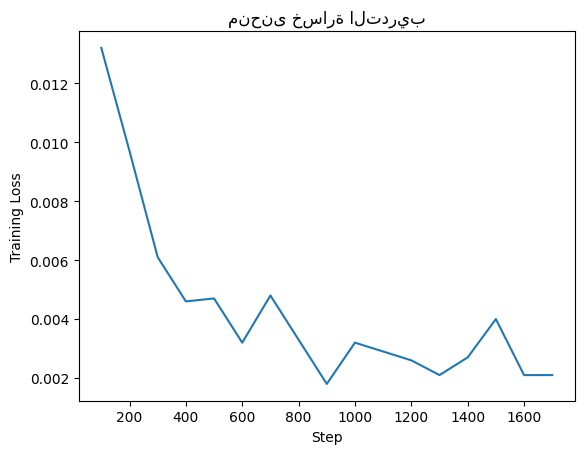

<Figure size 640x480 with 0 Axes>

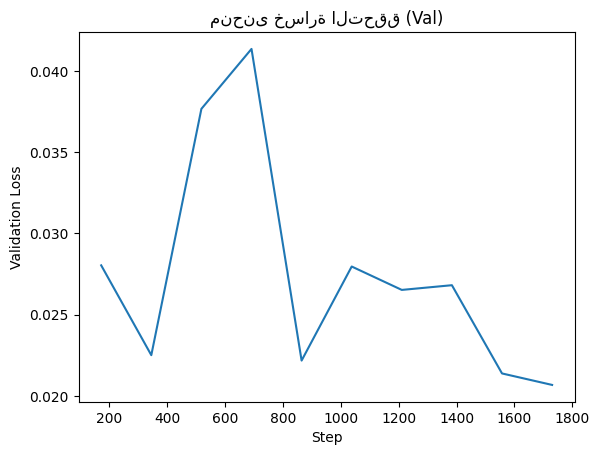

<Figure size 640x480 with 0 Axes>

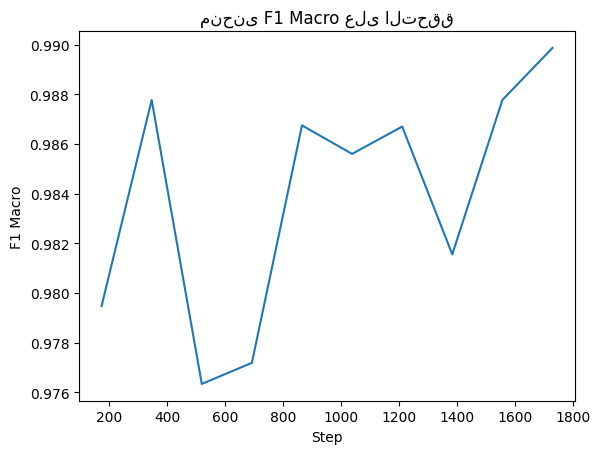

In [27]:
import pandas as pd
import matplotlib.pyplot as plt

# اجمع السجل من HuggingFace Trainer
hist = trainer.state.log_history

rows = []
for h in hist:
    r = {}
    r["step"]  = h.get("step", None)
    r["epoch"] = h.get("epoch", None)
    if "loss" in h:       r["train_loss"] = h["loss"]
    if "eval_loss" in h:  r["eval_loss"]  = h["eval_loss"]
    if "eval_f1_macro" in h: r["eval_f1_macro"] = h["eval_f1_macro"]
    if len(r) > 2: rows.append(r)

df = pd.DataFrame(rows).sort_values(["step"]).reset_index(drop=True)

# 1) منحنى خسارة التدريب
plt.figure()
df[["step","train_loss"]].dropna().plot(x="step", y="train_loss", legend=False)
plt.xlabel("Step"); plt.ylabel("Training Loss"); plt.title("منحنى خسارة التدريب")
plt.show()

# 2) منحنى Val Loss
plt.figure()
df[["step","eval_loss"]].dropna().plot(x="step", y="eval_loss", legend=False)
plt.xlabel("Step"); plt.ylabel("Validation Loss"); plt.title("منحنى خسارة التحقق (Val)")
plt.show()

# 3) منحنى F1 Macro
plt.figure()
df[["step","eval_f1_macro"]].dropna().plot(x="step", y="eval_f1_macro", legend=False)
plt.xlabel("Step"); plt.ylabel("F1 Macro"); plt.title("منحنى F1 Macro على التحقق")
plt.show()

In [23]:
import shutil
from google.colab import files

# مسار المجلد اللي فيه الموديل
src = "/content/best-model"
# مسار ملف الـ ZIP النهائي
zip_path = "/content/best-model.zip"

# اضغط المجلد إلى ZIP
shutil.make_archive("/content/best-model", 'zip', src)

# نزّل الملف المضغوط
files.download(zip_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>